<a href="https://colab.research.google.com/github/deductiveclouds/Pytorch/blob/giri/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

2.5.1+cu121


## 1. What are 3 areas in industry where computer vision is currently being used?

In [3]:
print('"Healthcare imaging", "Home security" and "Driverless cars".')

"Healthcare imaging", "Home security" and "Driverless cars".


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
print('"Overfitting" is when a model performs well on a train dataset but fails to generalize to an unseen dataset.')

"Overfitting" is when a model performs well on a train dataset but fails to generalize to an unseen dataset.


## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
print('"Proper feature selection", "Introduce regularization" and "Increase training data variety and size".')

"Proper feature selection", "Introduce regularization" and "Increase training data variety and size".


## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
import torch
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_data = MNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='data', train=False, download=True, transform=ToTensor())

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 146MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 57.6MB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 43.9MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.60MB/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [7]:
train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 6. Visualize at least 5 different samples of the MNIST training dataset.

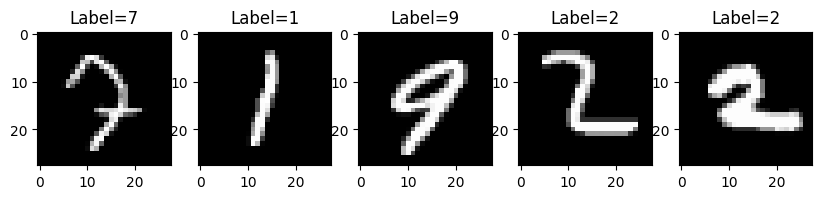

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
for i in range(5):
  index = torch.randint(low=0, high=len(train_data), size=(1,)).item()
  image = train_data[index][0]
  label = train_data[index][1]
  plt.subplot(1, 5, i+1)
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f'Label={label}')

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [9]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)
len(train_dataloader), len(test_dataloader)

(1875, 313)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [10]:
from re import M
from torch import nn

class MNISTModel(nn.Module):
  def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()
    self.cnn_block1 = nn.Sequential(nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2))
    self.cnn_block2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2))
    self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)) # Refer video 124 of PyTorch between time 8-12 mins for explanation on how 7*7 is arrived at.

  def forward(self, x):
    x = self.cnn_block1(x)
    x = self.cnn_block2(x)
    x = self.classifier(x)
    return x

model = MNISTModel(input_shape=1, hidden_units=10, output_shape=10).to(device=device)
model

MNISTModel(
  (cnn_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [11]:
%%time

from tqdm.auto import tqdm

EPOCHS = 3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

for epoch in tqdm(range(EPOCHS)):
  model.train()
  train_loss = 0
  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(train_dataloader)

  test_loss = 0
  model.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      test_loss += loss_fn(y_pred, y)
    test_loss /= len(test_dataloader)

  print(f'Epoch: {epoch} | Train loss: {train_loss:.3f} | Test loss: {test_loss:.3f}')


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.223 | Test loss: 0.067
Epoch: 1 | Train loss: 0.070 | Test loss: 0.049
Epoch: 2 | Train loss: 0.054 | Test loss: 0.043
CPU times: user 5min 28s, sys: 889 ms, total: 5min 29s
Wall time: 1min 22s


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

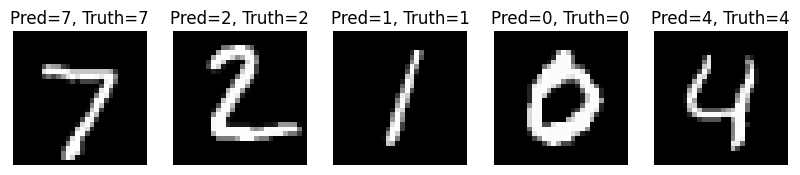

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for i in range(5):
  index = torch.randint(low=0, high=len(test_dataloader), size=(1,)).item()
  image = test_data[i][0]
  x = model(image.unsqueeze(dim=0))
  x = torch.softmax(x, dim=1)
  x = torch.argmax(x, dim=1).item()
  plt.subplot(1, 5, i+1)
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f'Pred={x}, Truth={test_data[i][1]}')
  plt.axis(False)

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [46]:
try:
  import torchmetrics, mlxtend
  assert int(mlxtend.__version__.split(',')[1]) >= 19, 'need to upgrade mlxtend'
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
print(f'mlxtend version: {mlxtend.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.6 MB/s eta 0:00:00
mlxtend version: 0.23.4


In [47]:
from tqdm.auto import tqdm

model.eval()

y_preds = []

with torch.inference_mode():
  for batch, (X, y) in tqdm(enumerate(test_dataloader)):
    X, y = X.to(device), y.to(device)
    logits = model(X)
    preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
    y_preds.append(preds)
  y_preds = torch.cat(y_preds).cpu()

len(y_preds)

0it [00:00, ?it/s]

10000

In [49]:
y_preds[:5], test_data.targets[:5]

(tensor([7, 2, 1, 0, 4]), tensor([7, 2, 1, 0, 4]))

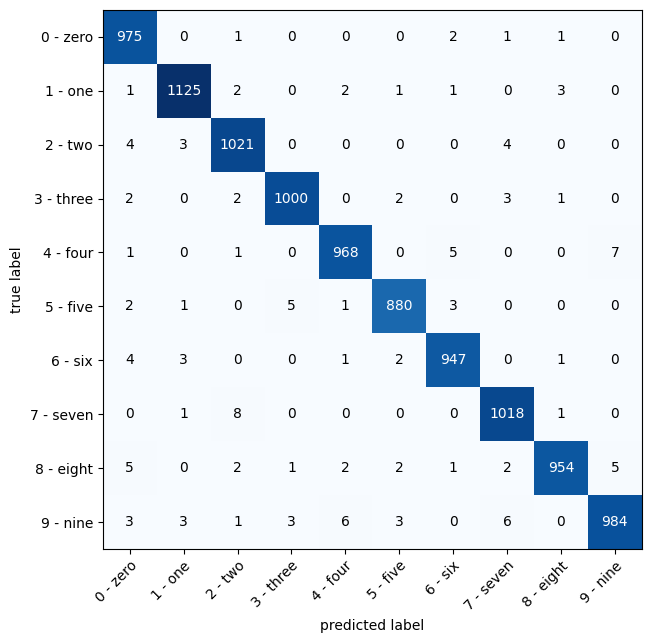

In [53]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

class_names = train_data.classes
confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confusion_matrix_tensor = confusion_matrix(preds=y_preds, target=test_data.targets)

fig, axes = plot_confusion_matrix(conf_mat=confusion_matrix_tensor.numpy(), class_names=class_names, figsize=(10, 7))

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [63]:
random_tensor = torch.rand([2, 3, 32, 32])
cnn_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=2, stride=2, padding=2)
print(f'Original shape: {random_tensor.shape} | Conv2D shape: {cnn_layer(random_tensor).shape}')

Original shape: torch.Size([2, 3, 32, 32]) | Conv2D shape: torch.Size([2, 32, 18, 18])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [72]:
from torchvision.datasets import FashionMNIST
from tqdm.auto import tqdm


train_data = FashionMNIST(root='data', train=True, transform=ToTensor(), download=True)
test_data =  FashionMNIST(root='data', train=False, transform=ToTensor(), download=True)

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

for epoch in tqdm(range(EPOCHS)):
  model.train()
  train_loss = 0
  train_acc = 0
  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    preds = model(X)
    loss = loss_fn(preds, y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(train_dataloader)

  model.eval()
  test_loss = 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)
      preds = model(X)
      test_loss += loss_fn(preds, y)
    test_loss /= len(test_dataloader)

  print(f'Epoch: {epoch} | Train loss: {train_loss:.3f} | Test loss: {test_loss:.3f}')

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.337 | Test loss: 0.349
Epoch: 1 | Train loss: 0.309 | Test loss: 0.334
Epoch: 2 | Train loss: 0.295 | Test loss: 0.326
